# DBSCAN Implementation Example

This notebook demonstrates how to train and visualize clustering results with the custom `rice_ml` DBSCAN implementation.

In [3]:
# Fit DBSCAN and inspect discovered clusters
model = DBSCAN(eps=0.9, min_samples=5)
labels = model.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Unique labels: {np.unique(labels)}")

Number of clusters: 2
Number of noise points: 4
Unique labels: [-1  0  1]


In [4]:
# Plot clustering results using the model utility
model.plot_clusters(X)

AttributeError: 'DBSCAN' object has no attribute 'plot_clusters'

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rice_ml.Unsupervised_Learning.dbscan import DBSCAN 

from rice_ml.processing.preprocessing import standardize
from rice_ml.processing.postprocessing import PostProcessor

from sklearn.datasets import make_blobs

# Set the Seaborn theme
sns.set_theme()

# Cluster Creation and Exploration

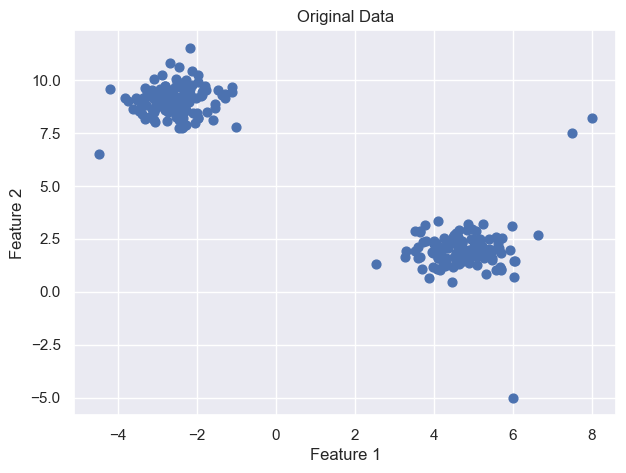

In [9]:
# Generate synthetic data with 2 dense clusters and a few outliers
X, _ = make_blobs(n_samples=250, centers=2, cluster_std=0.65, random_state=42)

noise = np.array([
    [7.5, 7.5],
    [8.0, 8.2],
    [-4.5, 6.5],
    [6.0, -5.0],
])
X = np.vstack([X, noise])

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Preprocessing
No splitting required

In [10]:
# Standardization
X_scaled = standardize(X)
# Model Training
# Fit DBSCAN and inspect discovered clusters
model = DBSCAN(eps=0.9, min_samples=5)
labels = model.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f"DBSCAN trained successfully.")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Unique labels: {np.unique(labels)}")

DBSCAN trained successfully.
Number of clusters: 2
Number of noise points: 3
Unique labels: [-1  0  1]


# Prediction and Evaluation

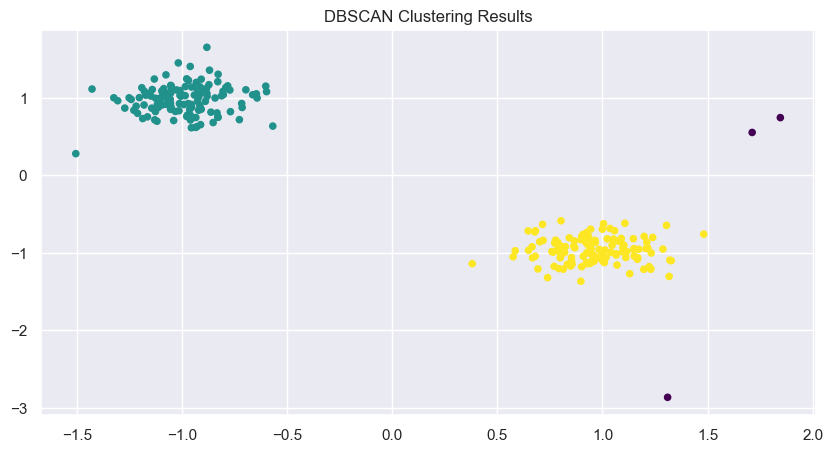

In [11]:
processor = PostProcessor()

# Plotting the results
plt.figure(figsize=(10, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=20)
plt.title("DBSCAN Clustering Results")
plt.show()
